(551, 1280, 3)


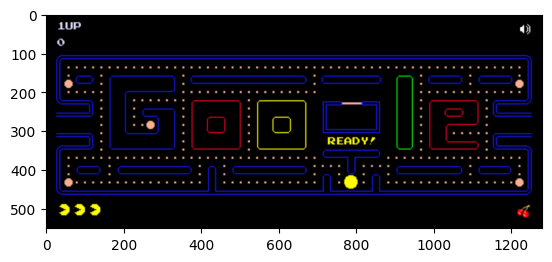

In [642]:
import cv2 as cv
import matplotlib.pyplot as plt

# [:,:,::-1]
testimage = cv.imread("./tests_folder/my_capture.png")
print(testimage.shape)
#rgbimage = cv.cvtColor(testimage, cv.COLOR_BGR2RGB)
plt.imshow(testimage[:,:,::-1])
#plt.imshow(rgbimage)

Score read by pytesseract :  READY?



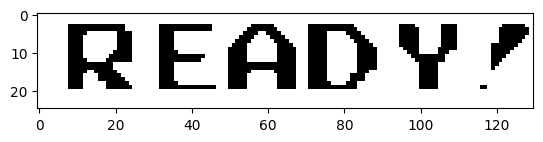

In [643]:
import pytesseract


# Tester la plateforme avant d'ajouter cette ligne
# import plateform
# platform.system()
pytesseract.pytesseract.tesseract_cmd = r'C:\Users\20190511\AppData\Local\Programs\Tesseract-OCR\tesseract'

displayGameMsgImg = testimage[315:340,720:850]
grayscaleimg = cv.cvtColor(displayGameMsgImg, cv.COLOR_RGB2GRAY)
threshold, thresh = cv.threshold(grayscaleimg, 120, 255, cv.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray')
displayedGameMsg = pytesseract.image_to_string(thresh)
print("Score read by pytesseract : ", displayedGameMsg)

In [644]:
import os
print(os.name) # display 'nt'

import platform
print(platform.system()) # display 'Windows'

nt
Windows


Score read by pytesseract :  0



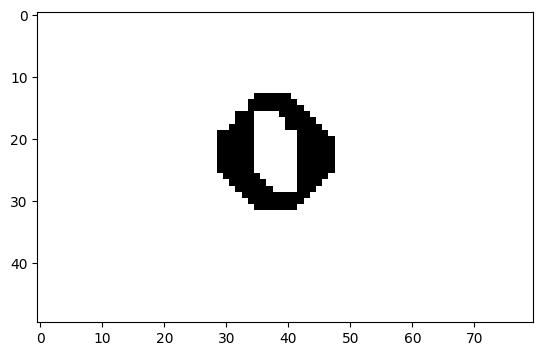

In [645]:


displayScoreImg = testimage[50:100,0:80]
grayscaleScoreImg = cv.cvtColor(displayScoreImg, cv.COLOR_RGB2GRAY)
threshold, thresh = cv.threshold(grayscaleScoreImg, 100, 180, cv.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray')
custom_config = r'--oem 3 --psm 10 -c tessedit_char_whitelist=0123456789'
displayedGameMsg = pytesseract.image_to_string(thresh, config=custom_config)
print("Score read by pytesseract : ", displayedGameMsg)
#gray = cv.cvtColor(displayScoreImg, cv.COLOR_RGB2GRAY)
#ret, thresh = cv.threshold(gray,25, 110, cv.THRESH_BINARY)
## displayScore = pytesseract.image_to_string(testimage[:,:,::-1])
## plt.imshow(testimageblurred[:,:,::-1])
## print("Score read by pytesseract : ", displayScore)


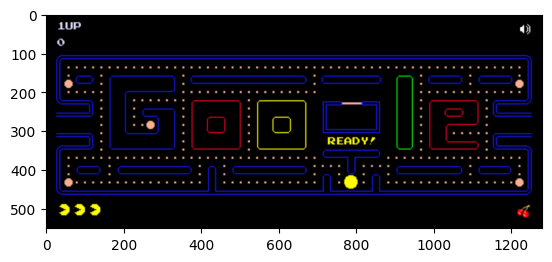

In [646]:
gray =cv.cvtColor(testimage, cv.COLOR_BGR2GRAY)
ret,binary = cv.threshold(gray,127,255,cv.THRESH_BINARY)
plt.imshow(testimage[:,:,::-1])

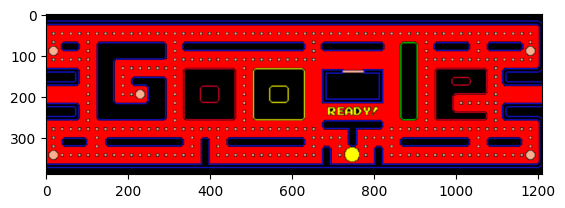

In [647]:
maze = testimage[90:480,40:1250].copy()
cv.floodFill(maze, None, (5,200), (0,0,255))
plt.imshow(maze[:,:,::-1])

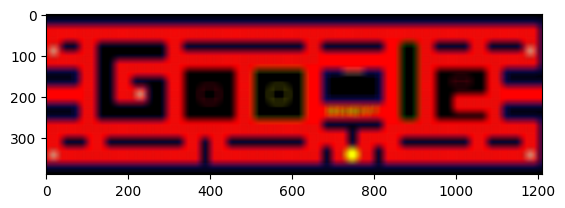

In [648]:
blurredMaze = cv.GaussianBlur(maze, (23,23), 20)
plt.imshow(blurredMaze[:,:,::-1])

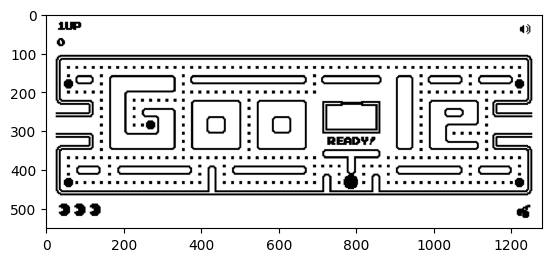

In [649]:
import numpy as np
frame_HSV = cv.cvtColor(testimage, cv.COLOR_BGR2HSV)
lower_blue = np.array([0, 0, 0])
upper_blue = np.array([90, 88, 100])
frame_threshold = cv.inRange(frame_HSV, lower_blue, upper_blue)
plt.imshow(frame_threshold, cmap="gray")

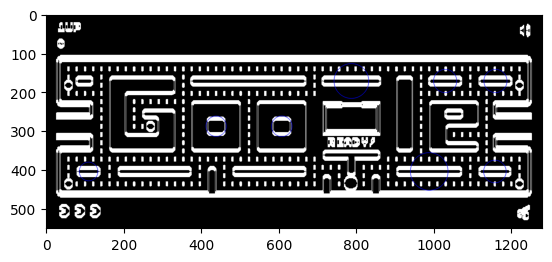

In [650]:
canny = cv.Canny(testimage, 180, 255)
# opening = cv.morphologyEx(canny, cv.MORPH_OPEN, (3,3))
# eroded = cv.erode(canny, (1,1))
dilate = cv.dilate(canny, (9,9), iterations=7)
#eroded = cv.erode(dilate, (3,3), iterations=9)


params = cv.SimpleBlobDetector_Params()

# Change thresholds
params.minThreshold = 10
params.maxThreshold = 200

# Filter by Area.
params.filterByArea = True
params.minArea = 1500

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.1

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.87

# Filter by Inertia
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
# OLD: detector = cv2.SimpleBlobDetector(params)
detector = cv.SimpleBlobDetector_create(params)


# Detect blobs.
keypoints = detector.detect(dilate)

# Draw detected blobs as red circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures
# the size of the circle corresponds to the size of blob

im_with_keypoints = cv.drawKeypoints(dilate, keypoints, np.array([]), (0,0,255), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


plt.imshow(im_with_keypoints, cmap="gray")

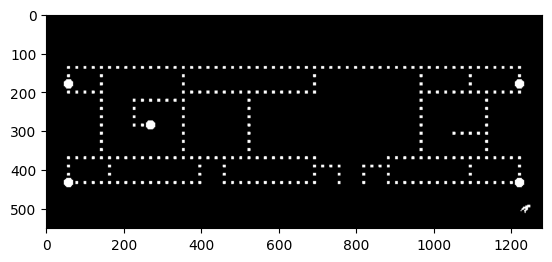

In [651]:
# testimageblurred = cv.GaussianBlur(testimage, (15, 15), 0)
frame_HSV = cv.cvtColor(testimage, cv.COLOR_BGR2HSV)
lower_blue = np.uint8([5, 5,5])
upper_blue = np.uint8([25, 255, 255])

frame_threshold_pacgums = cv.inRange(frame_HSV, lower_blue, upper_blue)
## frame_threshold_pacgums = cv.dilate(frame_threshold_pacgums, (17, 153), iterations=19)
plt.imshow(frame_threshold_pacgums, cmap="gray")
#plt.imshow(testimageblurred[:,:,::-1])
## dot_blue = np.uint8([[[9,107,248]]])
## hsv_dot_blue = cv.cvtColor(dot_blue,cv.COLOR_BGR2HSV)
## print(hsv_dot_blue)

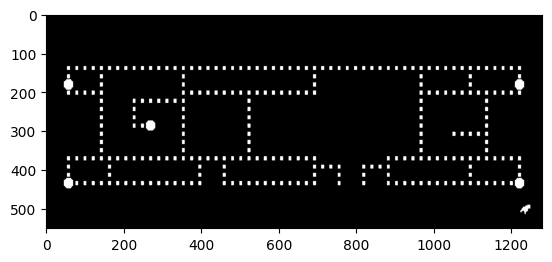

In [652]:
# maskInversion = cv.bitwise_not(frame_threshold_pacgums)
threshold, maskInversion = cv.threshold(frame_threshold_pacgums, 90, 255, cv.THRESH_BINARY)
maskInversion = cv.dilate(frame_threshold_pacgums, (97, 17), iterations=3)
plt.imshow(maskInversion, cmap="gray")
maskInversion = cv.bitwise_not(frame_threshold_pacgums)
# plt.imshow(maskInversion, cmap="gray")
#pacgumRemoved = cv.bitwise_and(testimage, testimage, mask=maskInversion)
#plt.imshow(pacgumRemoved[:,:,::-1])

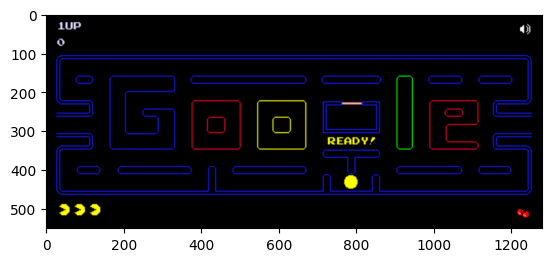

In [653]:
pacgumRemoved = cv.bitwise_and(testimage, testimage, mask=maskInversion)
plt.imshow(pacgumRemoved[:,:,::-1])

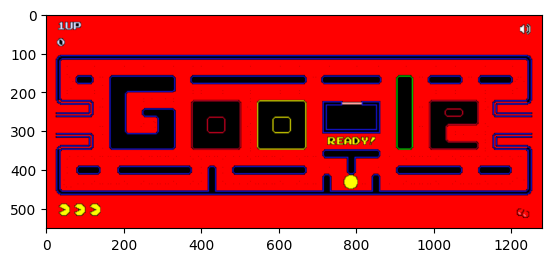

In [654]:
floodfillArtifact = pacgumRemoved.copy()
# floodfillArtifact = cv.GaussianBlur(floodfillArtifact, (9, 9), 50)
# plt.imshow(floodfillArtifact[:,:,::-1])
cv.floodFill(floodfillArtifact, None, (0,0), (0, 0, 255))
plt.imshow(floodfillArtifact[:,:,::-1])

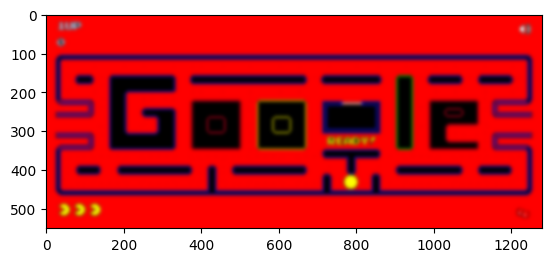

In [655]:
blurred = cv.GaussianBlur(floodfillArtifact, (29,29), 0)
plt.imshow(blurred[:,:,::-1])

[[[ 52 242  20]]]


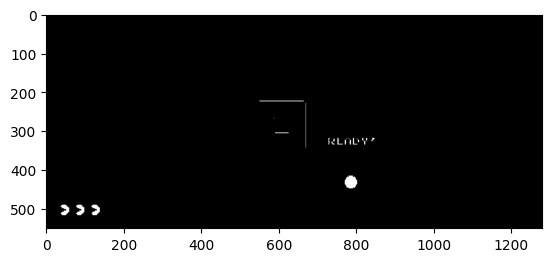

In [656]:
frame_HSV = cv.cvtColor(testimage, cv.COLOR_BGR2HSV)
lower_yellow = np.uint8([28, 250,250])
upper_yellow = np.uint8([30, 255, 255])

frame_threshold_pacman = cv.inRange(frame_HSV, lower_yellow, upper_yellow)
frame_threshold_pacman = cv.dilate(frame_threshold_pacman, (19,19))
plt.imshow(frame_threshold_pacman, cmap="gray")

dot_blue = np.uint8([[[1,20,6]]])
hsv_dot_blue = cv.cvtColor(dot_blue,cv.COLOR_BGR2HSV)
print(hsv_dot_blue)

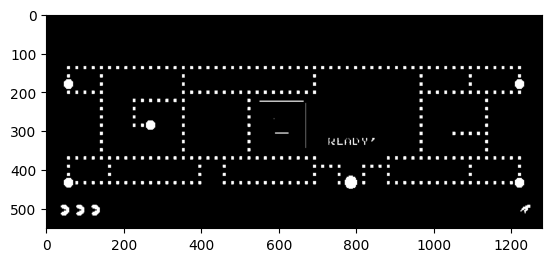

In [657]:
combinedMask = cv.bitwise_or(frame_threshold_pacman, frame_threshold_pacgums)
combinedMask = cv.dilate(combinedMask, (3,99))
plt.imshow(combinedMask, cmap="gray")

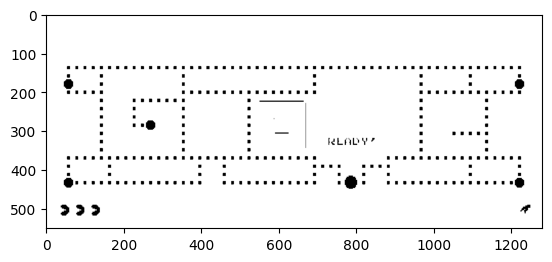

In [658]:
maskInversion = cv.bitwise_not(combinedMask)
plt.imshow(maskInversion, cmap="gray")

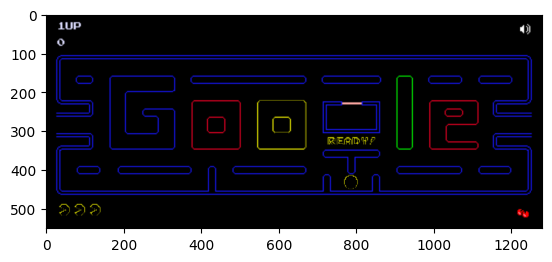

In [659]:
pacgumRemoved = cv.bitwise_and(testimage, testimage, mask=maskInversion)
plt.imshow(pacgumRemoved[:,:,::-1])

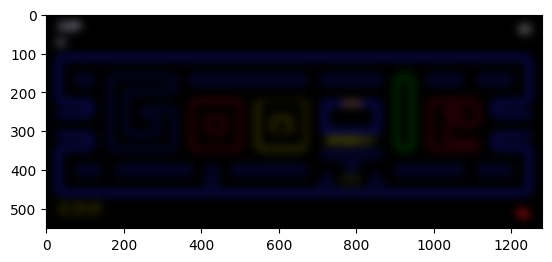

In [660]:
blurred = cv.GaussianBlur(pacgumRemoved, (79,79), 0)
plt.imshow(blurred[:,:,::-1])

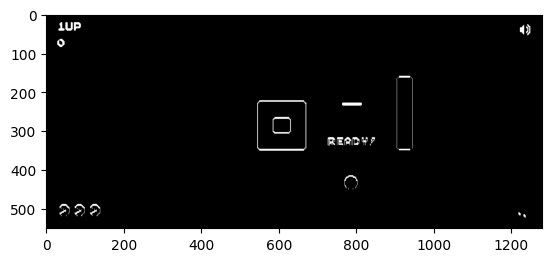

In [661]:
floodfillArtifact = pacgumRemoved.copy()
gray = cv.cvtColor(floodfillArtifact, cv.COLOR_BGR2GRAY)
dilation = cv.dilate(gray, (7,7), iterations=3)
threshold, floodfillthresh = cv.threshold(dilation, 120, 155, cv.THRESH_BINARY)

plt.imshow(floodfillthresh, cmap="gray")
## cv.floodFill(floodfillArtifact, None, (0,0), (25, 255, 255))
## plt.imshow(floodfillArtifact[:,:,::-1])

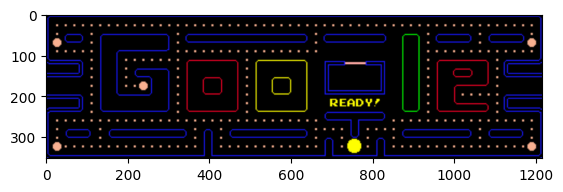

In [662]:
maze = testimage[110:462,31:1247].copy()
maze_rgb = cv.cvtColor(maze, cv.COLOR_BGR2RGB)
#cv.floodFill(maze, None, (5,190), (0,0,255))
plt.imshow(maze_rgb)

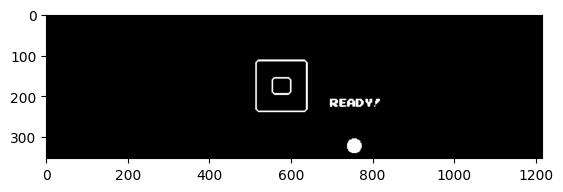

In [663]:
lower_yellow = np.uint8([55, 55,0])
upper_yellow = np.uint8([255, 255, 0])

frame_threshold_pacman = cv.inRange(maze_rgb, lower_yellow, upper_yellow)
eroded = cv.erode(frame_threshold_pacman, (17,17))
plt.imshow(frame_threshold_pacman, cmap="gray")

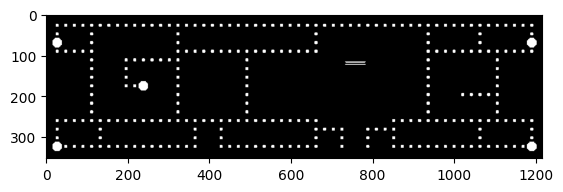

In [664]:
lower_yellow = np.uint8([21, 15, 12])
upper_yellow = np.uint8([248, 176, 144])

frameThreshPac = cv.inRange(maze_rgb, lower_yellow, upper_yellow)
plt.imshow(frameThreshPac, cmap="gray")
## frameThreshPac = cv.threshold(frameThreshPac, 0, 100, cv.THRESH_BINARY)
## print(frameThreshPac)
## plt.imshow(frameThreshPac, cmap="gray")
## frame_threshold_pacman = cv.dilate(frame_threshold_pacman, (17,17))
#plt.imshow(frame_threshold_pacman, cmap="gray")

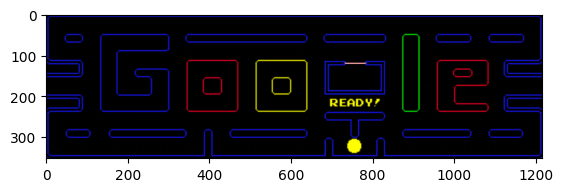

In [665]:
maskInversion = cv.bitwise_not(frameThreshPac)
pacgumRemoved = cv.bitwise_and(maze_rgb, maze_rgb, mask=maskInversion)
plt.imshow(pacgumRemoved)

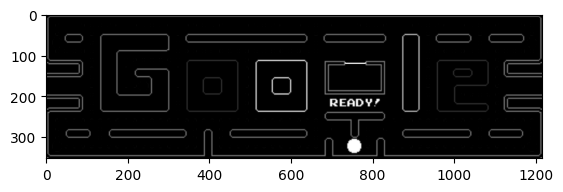

In [666]:
pacgumRemovedGray = cv.cvtColor(pacgumRemoved, cv.COLOR_BGR2GRAY)
plt.imshow(pacgumRemovedGray, cmap="gray")

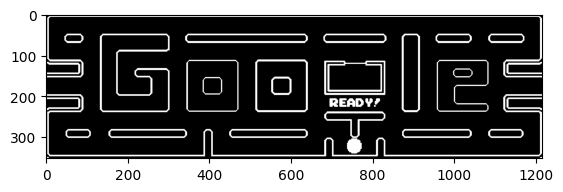

In [667]:
threshold, mythresh = cv.threshold(pacgumRemovedGray, 16, 255, cv.THRESH_BINARY)
plt.imshow(mythresh, cmap="gray")

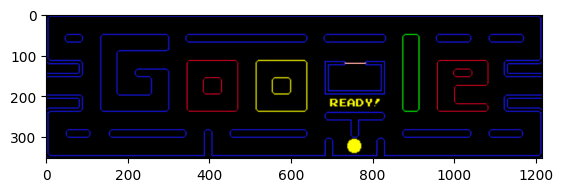

In [668]:
myMaze = cv.bitwise_and(pacgumRemoved, pacgumRemoved, mask=mythresh)
plt.imshow(myMaze)

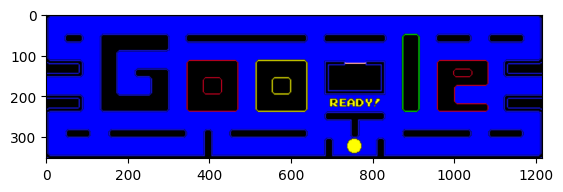

In [669]:
myMazeCopy = myMaze.copy()
#myMazeBlurred = cv.GaussianBlur(myMazeCopy, (29, 29), 50)
# plt.imshow(floodfillArtifact[:,:,::-1])
cv.floodFill(myMazeCopy, None, (0,180), (0,0,255))
plt.imshow(myMazeCopy)

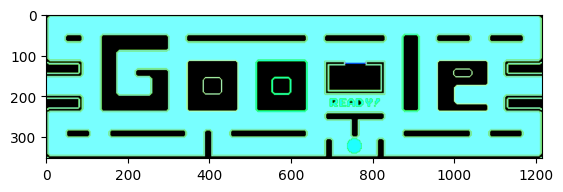

In [670]:
hsv = cv.cvtColor(myMazeCopy, cv.COLOR_RGB2HSV)
plt.imshow(hsv)

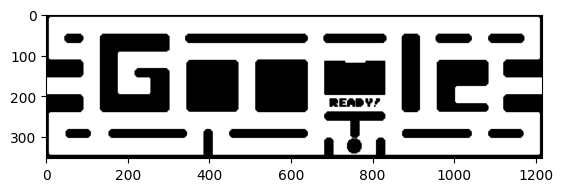

In [671]:
lower_yellow = np.uint8([115, 250, 250])
upper_yellow = np.uint8([120, 255, 255])

frameThreshPac = cv.inRange(hsv, lower_yellow, upper_yellow)
plt.imshow(frameThreshPac, cmap="gray")

In [672]:
cv.imwrite("./tests_folder/binarizedMaze.png", frameThreshPac)

True

In [673]:
dot_blue = np.uint8([[[0,255,255]]])
hsv_dot_blue = cv.cvtColor(dot_blue,cv.COLOR_RGB2HSV)
print(hsv_dot_blue)

[[[ 90 255 255]]]


In [674]:
dot_blue = np.uint8([[[3,200,160]]])
hsv_dot_blue = cv.cvtColor(dot_blue,cv.COLOR_RGB2HSV)
print(hsv_dot_blue)

[[[ 84 251 200]]]


### Le code parfait est sous cette ligne

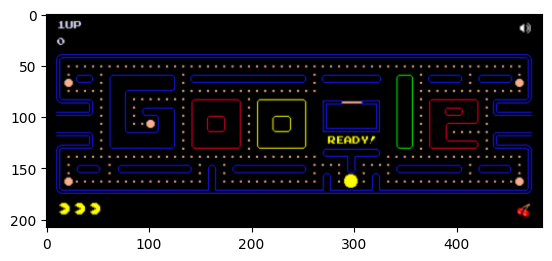

In [675]:
import numpy as np

reduced_frame = cv.resize(testimage, (484, 208), interpolation=cv.INTER_AREA)
plt.imshow(reduced_frame[:,:,::-1])

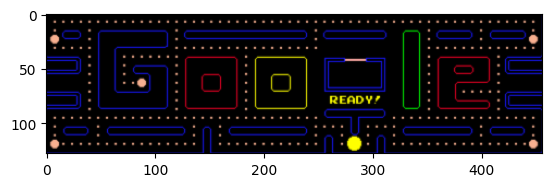

In [676]:
maze = reduced_frame[44:172,14:470].copy()
maze_rgb = cv.cvtColor(maze, cv.COLOR_BGR2RGB)
#cv.floodFill(maze, None, (5,190), (0,0,255))
plt.imshow(maze_rgb)

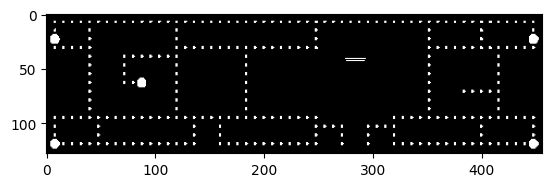

In [677]:
lower_yellow = np.uint8([30, 20, 20])
upper_yellow = np.uint8([248, 176, 144])

frameThreshPac = cv.inRange(maze_rgb, lower_yellow, upper_yellow)
plt.imshow(frameThreshPac, cmap="gray")

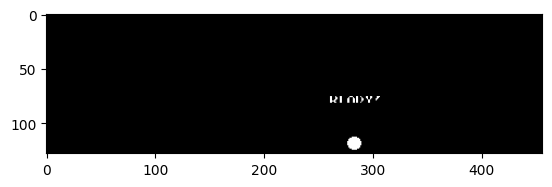

In [678]:
lower_yellow = np.uint8([196, 195,0])  # [248, 248,0]
upper_yellow = np.uint8([255, 255, 0])

frame_threshold_pacman = cv.inRange(maze_rgb, lower_yellow, upper_yellow)
eroded = cv.erode(frame_threshold_pacman, (17,17))
plt.imshow(frame_threshold_pacman, cmap="gray")

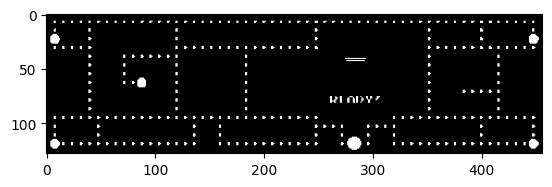

In [679]:
combinedMask = np.bitwise_or(frameThreshPac, frame_threshold_pacman)
plt.imshow(combinedMask, cmap="gray")

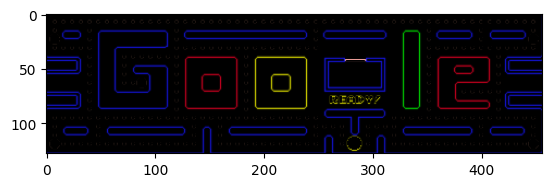

In [680]:
maskInversion = cv.bitwise_not(combinedMask)
pacgumRemoved = cv.bitwise_and(maze_rgb, maze_rgb, mask=maskInversion)
plt.imshow(pacgumRemoved)

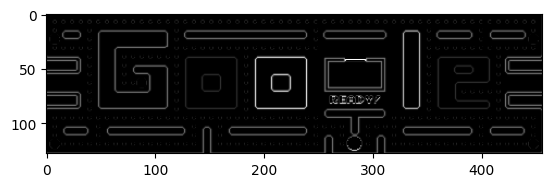

In [681]:
pacgumRemovedGray = cv.cvtColor(pacgumRemoved, cv.COLOR_BGR2GRAY)
plt.imshow(pacgumRemovedGray, cmap="gray")

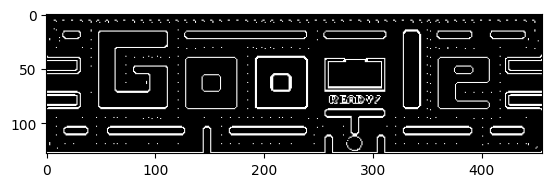

In [682]:
threshold, mythresh = cv.threshold(pacgumRemovedGray, 20, 255, cv.THRESH_BINARY)
plt.imshow(mythresh, cmap="gray")

In [683]:
import cv2 as cv
flags = [i for i in dir(cv) if i.startswith('COLOR_')]
for flag in flags:
    print(flag)


COLOR_BAYER_BG2BGR
COLOR_BAYER_BG2BGRA
COLOR_BAYER_BG2BGR_EA
COLOR_BAYER_BG2BGR_VNG
COLOR_BAYER_BG2GRAY
COLOR_BAYER_BG2RGB
COLOR_BAYER_BG2RGBA
COLOR_BAYER_BG2RGB_EA
COLOR_BAYER_BG2RGB_VNG
COLOR_BAYER_BGGR2BGR
COLOR_BAYER_BGGR2BGRA
COLOR_BAYER_BGGR2BGR_EA
COLOR_BAYER_BGGR2BGR_VNG
COLOR_BAYER_BGGR2GRAY
COLOR_BAYER_BGGR2RGB
COLOR_BAYER_BGGR2RGBA
COLOR_BAYER_BGGR2RGB_EA
COLOR_BAYER_BGGR2RGB_VNG
COLOR_BAYER_GB2BGR
COLOR_BAYER_GB2BGRA
COLOR_BAYER_GB2BGR_EA
COLOR_BAYER_GB2BGR_VNG
COLOR_BAYER_GB2GRAY
COLOR_BAYER_GB2RGB
COLOR_BAYER_GB2RGBA
COLOR_BAYER_GB2RGB_EA
COLOR_BAYER_GB2RGB_VNG
COLOR_BAYER_GBRG2BGR
COLOR_BAYER_GBRG2BGRA
COLOR_BAYER_GBRG2BGR_EA
COLOR_BAYER_GBRG2BGR_VNG
COLOR_BAYER_GBRG2GRAY
COLOR_BAYER_GBRG2RGB
COLOR_BAYER_GBRG2RGBA
COLOR_BAYER_GBRG2RGB_EA
COLOR_BAYER_GBRG2RGB_VNG
COLOR_BAYER_GR2BGR
COLOR_BAYER_GR2BGRA
COLOR_BAYER_GR2BGR_EA
COLOR_BAYER_GR2BGR_VNG
COLOR_BAYER_GR2GRAY
COLOR_BAYER_GR2RGB
COLOR_BAYER_GR2RGBA
COLOR_BAYER_GR2RGB_EA
COLOR_BAYER_GR2RGB_VNG
COLOR_BAYER_GRBG2BGR
COL

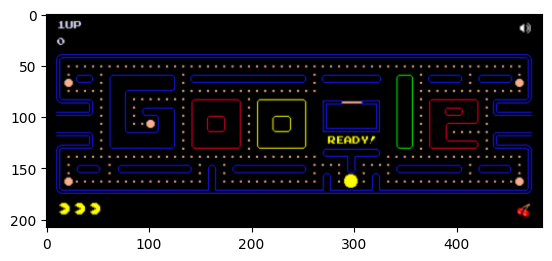

In [694]:
import numpy as np

reduced_frame = cv.resize(testimage, (484, 208), interpolation=cv.INTER_AREA)
plt.imshow(reduced_frame[:,:,::-1])

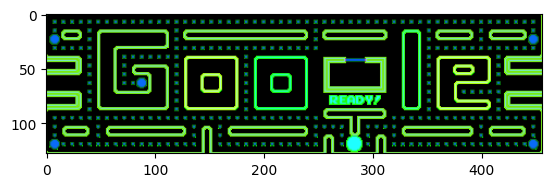

In [695]:
maze_bgr = reduced_frame[44:172,14:470].copy()
maze_hsv = cv.cvtColor(maze_bgr, cv.COLOR_BGR2HSV)
#cv.floodFill(maze, None, (5,190), (0,0,255))
plt.imshow(maze_hsv)

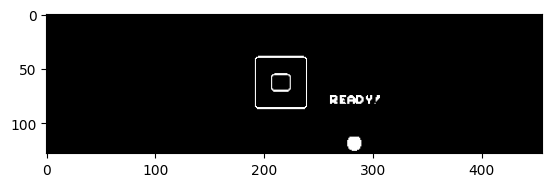

In [716]:
lower_yellow = np.uint8([30, 254, 55])  # 
upper_yellow = np.uint8([30, 255, 255])

frame_pacman_core = cv.inRange(maze_hsv, lower_yellow, upper_yellow)
plt.imshow(frame_pacman_core, cmap="gray")

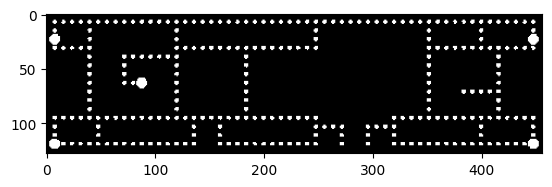

In [717]:
lower_yellow = np.uint8([8, 0, 0])  # 
upper_yellow = np.uint8([12, 255, 255])

pacgumsMask = cv.inRange(maze_hsv, lower_yellow, upper_yellow)
plt.imshow(pacgumsMask, cmap="gray")

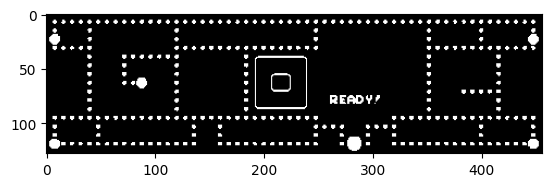

In [718]:
completeMask = np.bitwise_or(frame_pacman_core, pacgumsMask)
plt.imshow(completeMask, cmap="gray")

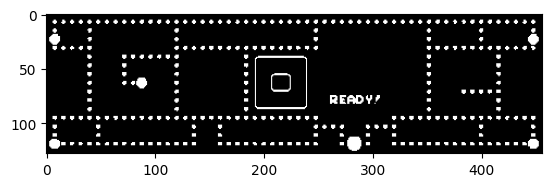

In [719]:
threshold, mythresh = cv.threshold(completeMask, 2, 255, cv.THRESH_BINARY)
plt.imshow(mythresh, cmap="gray")

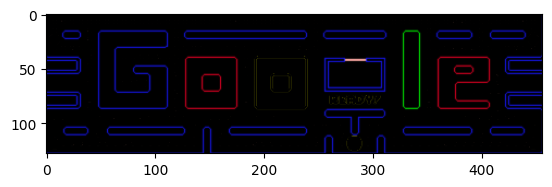

In [720]:
maskInversion = cv.bitwise_not(completeMask)
pacgumRemoved = cv.bitwise_and(maze_bgr, maze_bgr, mask=maskInversion)
plt.imshow(pacgumRemoved[:,:,::-1])

In [693]:
# Adding a black border around the original image

import numpy as np
import cv2

im = cv2.imread('image.jpg')
row, col = im.shape[:2]
bottom = im[row-2:row, 0:col]
mean = cv2.mean(bottom)[0]

border_size = 10
border = cv2.copyMakeBorder(
    im,
    top=border_size,
    bottom=border_size,
    left=border_size,
    right=border_size,
    borderType=cv2.BORDER_CONSTANT,
    value=[mean, mean, mean]
)

cv2.imshow('image', im)
cv2.imshow('bottom', bottom)
cv2.imshow('border', border)
cv2.waitKey(0)
cv2.destroyAllWindows()

AttributeError: 'NoneType' object has no attribute 'shape'

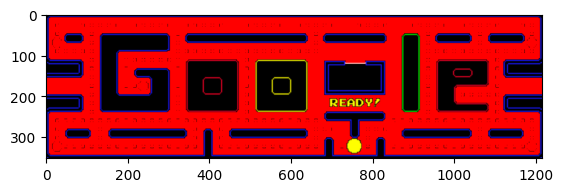

In [ ]:
myMazeCopy = pacgumRemoved.copy()
#myMazeBlurred = cv.GaussianBlur(myMazeCopy, (29, 29), 50)
# plt.imshow(floodfillArtifact[:,:,::-1])
cv.floodFill(myMazeCopy, None, (0,180), (255, 0, 0))
plt.imshow(myMazeCopy)

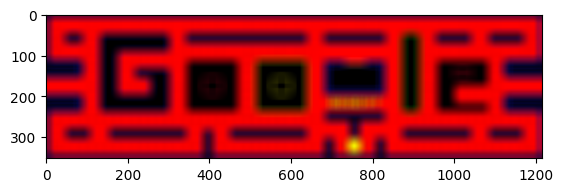

In [ ]:
myMazeBlurred = cv.GaussianBlur(myMazeCopy, (29, 29), 50)
plt.imshow(myMazeBlurred)

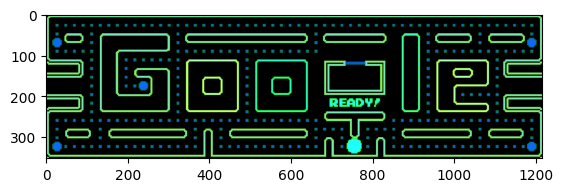

In [ ]:
maze_hsv = cv.cvtColor(maze, cv.COLOR_BGR2HSV)
#cv.floodFill(maze, None, (5,190), (0,0,255))
plt.imshow(maze_hsv)

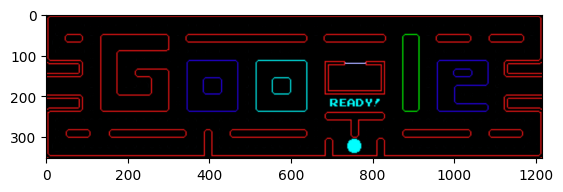

In [ ]:
floodfillArtifact = pacgumRemoved.copy()
# floodfillArtifact = cv.GaussianBlur(floodfillArtifact, (9, 9), 50)
# plt.imshow(floodfillArtifact[:,:,::-1])
cv.floodFill(floodfillArtifact, None, (0,0), (25, 255, 255))
plt.imshow(floodfillArtifact[:,:,::-1])

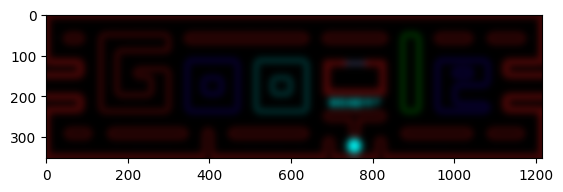

In [ ]:
blurredArtifact = cv.GaussianBlur(floodfillArtifact, (59,59), 0)
plt.imshow(blurredArtifact[:,:,::-1])

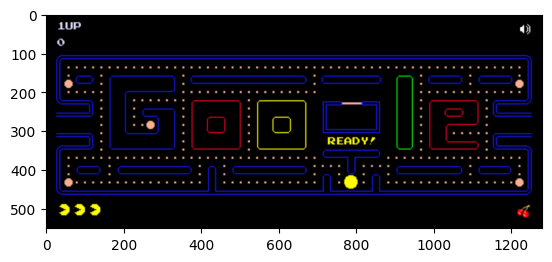

In [ ]:
plt.imshow(testimage[:,:,::-1])

c:\Users\20190511\OneDrive - Moby Analytics\Documents\PacmanSolver\.env\Lib\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


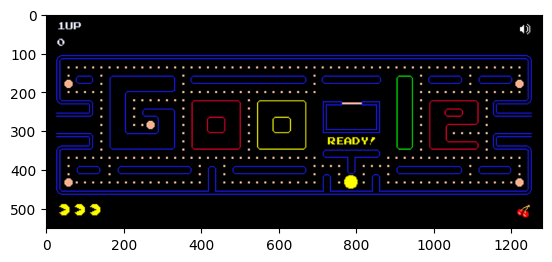

In [ ]:
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

# Sharpen the image
sharpened_image = cv.filter2D(testimage, -1, kernel)

plt.imshow(sharpened_image[:,:,::-1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-384.0..271.0].


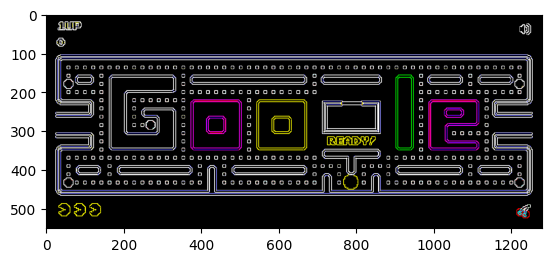

In [ ]:
sharpened_image2 = cv.Laplacian(testimage, cv.CV_64F)

plt.imshow(sharpened_image2[:,:,::-1])

32 32


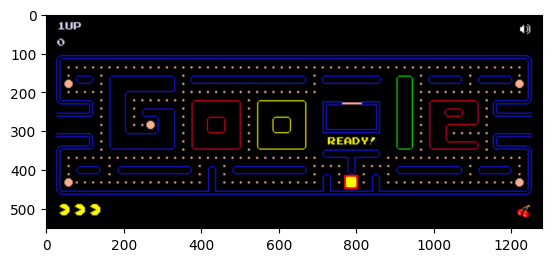

In [ ]:
import numpy as np

pureYellow = (255, 255, 0)
testImageRGB = cv.cvtColor(testimage, cv.COLOR_BGR2RGB)

mask = np.zeros(testImageRGB.shape[:])
mask[:] = (255, 255, 0) # pure yellow, color of pacman
result = np.where(np.all(testImageRGB == mask, axis=2), 255, 0).astype(np.uint8)


cnts,hierarchy = cv.findContours(result,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
cnt = sorted(cnts, key=cv.contourArea)
x,y,w,h = cv.boundingRect(cnt[-1])
print(w,h)
cv.rectangle(testImageRGB,(x,y),(x+w,y+h),(255, 0, 0),3)

plt.imshow(testImageRGB)

3


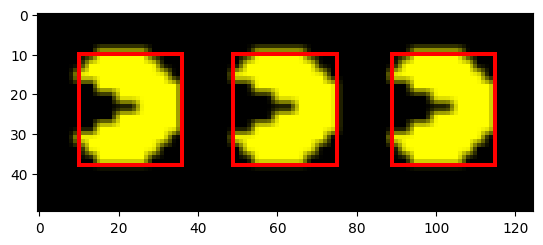

In [ ]:
pacLives = cv.cvtColor(testimage[480:530, 25:150].copy(), cv.COLOR_BGR2RGB)
grayscale = cv.cvtColor(pacLives, cv.COLOR_RGB2GRAY)
ret, binary = cv.threshold(grayscale,127,255,cv.THRESH_BINARY)
## mask = np.zeros(pacLives.shape[:])
## mask[:] = (255, 255, 0) # pure yellow, color of pacman
## result = np.where(np.all(pacLives == mask, axis=2), 255, 0).astype(np.uint8)
cnts,hierarchy = cv.findContours(binary,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
print(len(cnts))



for cnt in cnts:
    x,y,w,h = cv.boundingRect(cnt)
    cv.rectangle(pacLives,(x,y),(x+w,y+h),(255, 0, 0),1)

plt.imshow(pacLives)

In [ ]:
def rescaleFrame(frame, scale=0.75):
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale)
    dimensions = (width, height)

    return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)